A notebook for GLiNER model evaluation using nervaluate.

## Libraries

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"]="python"

import torch
from gliner import GLiNERConfig, GLiNER
from gliner.training import Trainer, TrainingArguments
from gliner.data_processing.collator import DataCollatorWithPadding, DataCollator
from gliner.utils import load_config_as_namespace
from gliner.data_processing import WordsSplitter, GLiNERDataset

from dataset_processing import *

from tqdm import tqdm

from typing import List, Dict, Set, Tuple
from seqeval.metrics.sequence_labeling import get_entities
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

## BiodivNER

THIS NEEDS TO BE ADJUSTED FOR BIODIVNER -> BIODIVNER FINETUNED MODEL IS NOT READY YE!

Load the model:

In [11]:
trained_model = GLiNER.from_pretrained("models/GLiNER_med_v2_1/BIODIVNER_PURE/checkpoint-486", load_tokenizer=True)
#("urchade/gliner_medium-v2.1")
#("models/GLiNER_med_v2_1/BIODIVNER_PURE/checkpoint-486", load_tokenizer=True)

config.json not found in /home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/GLINER/models/GLiNER_med_v2_1/BIODIVNER_PURE/checkpoint-486


Conversion to CONLL format for BiodivNER (should be ran once):

In [3]:

INPUT_DATA_DIRECTORY = "/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/BiodivNER/"
OUTPUT_DATA_DIRECTORY = "/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER/"

convert_biodivner_to_conll(input_dir=INPUT_DATA_DIRECTORY,output_dir=OUTPUT_DATA_DIRECTORY)

Converting '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/BiodivNER/test.csv' to '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER/test.txt'...
Converting '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/BiodivNER/dev.csv' to '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER/dev.txt'...
Converting '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/BiodivNER/train.csv' to '/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER/train.txt'...

Conversion complete.


BiodivNER test sentences preprocessing:

In [12]:
# Read the CSV file
input_path = INPUT_DATA_DIRECTORY + "test.csv"

df = pd.read_csv(input_path, encoding='latin1')
df.dropna(subset=['Word', 'Tag'], inplace=True)

# 3. The key step: Forward-fill the 'Sentence #' to group words correctly
df['Sentence #'] = df['Sentence #'].ffill()

# 4. Create sentences
sentences = []
for _, sentence_df in df.groupby('Sentence #'):
    temp_sent = []
    for _, row in sentence_df.iterrows():
        temp_sent.append(row["Word"])
    sentences.append(" ".join(temp_sent))

In [13]:
from tqdm import tqdm
predictions = dict()
labels = list(BIODIVNER_LABELS)

for i, sent in tqdm(enumerate(sentences)):
    entities = trained_model.predict_entities(sent, labels, threshold=0.1)

    prediction = {
        "text": sent,
        "ner": entities
    }
    
    predictions[f"sentence-{i}"] = prediction

0it [00:00, ?it/s]Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
23it [00:04,  5.52it/s]/home/p0l3/.local/lib/python3.10/site-packages/gliner/data_processing/processor.py:269: UserWarning: Sentence of length 2215 has been truncated to 384
  warnings.warn(f"Sentence of length {len(tokens)} has been truncated to {max_len}")
240it [00:51,  4.68it/s]


In [14]:
conll_output = convert_predictions_to_conll(predictions)

os.makedirs("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/GLiNER_med_v2_1/", exist_ok=True)

with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER_GLiNER_med_v2_1_BIODIVNER_PURE/pred.txt", "w") as f:
    f.write(conll_output)

## Climate-Change-NER (IBM)

Load model:

In [4]:
trained_model = GLiNER.from_pretrained("urchade/gliner_medium-v2.1")

# "models/GLiNER_med_v2_1/IBMCCNER_PURE/checkpoint-510", load_tokenizer=True)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/home/p0l3/miniforge3/envs/gliner/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Conversion to CONLL format for IBMCCNER (should be ran once):

In [7]:
ds = load_dataset(IBMCCNER_DIR) 

train_documentwise = []
temp_list = []
for line in ds["test"]["text"]:
    if line.strip().startswith('-DOCSTART-'):
        if temp_list:
            train_documentwise.append(temp_list)
        temp_list = []
    temp_list.append(line)
if temp_list:
    train_documentwise.append(temp_list)

conll_output = convert_ibmccner_to_conll(train_documentwise)

with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/IBMCCNER/test.txt", "w") as f:
    f.write(conll_output)

IBMCCNER test sentences preprocessing:

In [ ]:
with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/IBMCCNER/test.txt", "r") as f:
    file = f.read()
    
sentences = []
for document in re.split("-DOCSTART-	O\n", file.strip()):
    if len(document.strip()) != 0:
        temp_sent = []
        for word in re.split("\n", document.strip()):
            temp_sent.append(re.split("\t", word)[0])
        sentences.append(" ".join(temp_sent))

# print(sentences)

predictions = dict()
labels = list(IBMCCNER_LABELS)

for i, sent in tqdm(enumerate(sentences)):
    entities = trained_model.predict_entities(sent, labels, threshold=0.1)

    prediction = {
        "text": sent,
        "ner": entities
    }
    
    predictions[f"sentence-{i}"] = prediction


In [6]:
conll_output = convert_predictions_to_conll(predictions)

os.makedirs("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/GLiNER_med_v2_1/", exist_ok=True)

with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/GLiNER_med_v2_1/pred.txt", "w") as f:
    f.write(conll_output)

## Evaluation

In [20]:
anot_path = "/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/BiodivNER/test.txt"
pred_path = "/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/CONLL_FORMAT/GLiNER_med_v2_1/biodivner.txt"

with open(anot_path, "r") as f:
    anot = f.read()

with open(pred_path, "r") as f:
    pred = f.read()
    
from nervaluate import Evaluator
evaluator = Evaluator(anot, pred, tags=labels, loader="conll") # one example .split("\n\n")[1]

results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()

import pandas as pd

df = pd.DataFrame(results)
print(df)

print("\n##results##:\n")
print("Strict: ", results["strict"])
print("Exact:  ", results["exact"])
print("\##results_by_tag##:\n")
print(results_by_tag)
print("\##result_indices##:\n")
print(result_indices)
print("\##result_indices_by_tag##:\n")
print(result_indices_by_tag)

              ent_type      partial       strict        exact
correct     518.000000   427.000000   346.000000   427.000000
incorrect   259.000000     0.000000   431.000000   350.000000
partial       0.000000   350.000000     0.000000     0.000000
missed      631.000000   631.000000   631.000000   631.000000
spurious    728.000000   728.000000   728.000000   728.000000
possible   1408.000000  1408.000000  1408.000000  1408.000000
actual     1505.000000  1505.000000  1505.000000  1505.000000
precision     0.344186     0.400000     0.229900     0.283721
recall        0.367898     0.427557     0.245739     0.303267
f1            0.355647     0.413320     0.237556     0.293169

##results##:

Strict:  {'correct': 346, 'incorrect': 431, 'partial': 0, 'missed': 631, 'spurious': 728, 'possible': 1408, 'actual': 1505, 'precision': 0.22990033222591363, 'recall': 0.24573863636363635, 'f1': 0.23755578441469274}
Exact:   {'correct': 427, 'incorrect': 350, 'partial': 0, 'missed': 631, 'spurious': 72

### Visuals

#### Overall Metrics (Strict, Partial, Exact, Ent-Type) — Bar Chart

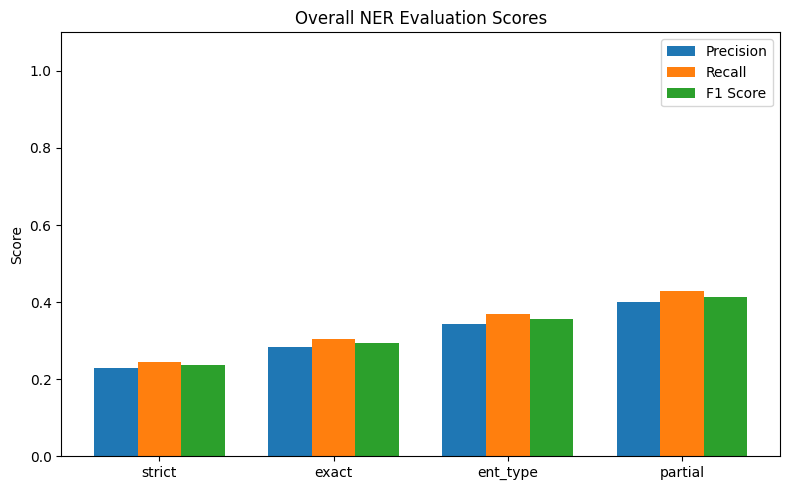

In [21]:
import matplotlib.pyplot as plt

def plot_overall_metrics(results):
    metrics = ['strict', 'exact', 'ent_type', 'partial']
    precision = [results[m]['precision'] for m in metrics]
    recall = [results[m]['recall'] for m in metrics]
    f1 = [results[m]['f1'] for m in metrics]

    x = range(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width for i in x], precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar([i + width for i in x], f1, width, label='F1 Score')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Overall NER Evaluation Scores")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metrics(results)

#### Per-Entity-Type F1 Score — Bar Chart (from results_by_tag)

['Environment', 'Location', 'Matter', 'Organism', 'Phenomena', 'Quality']


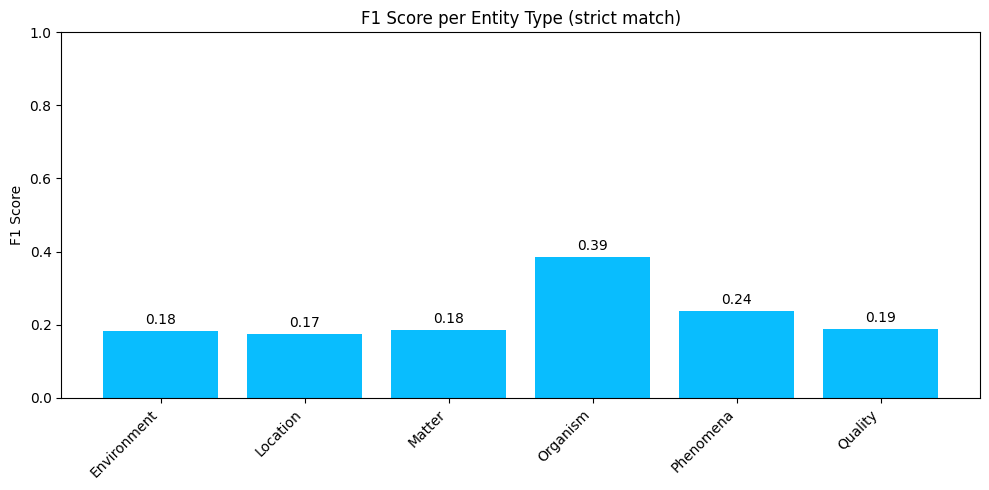

['Environment', 'Location', 'Matter', 'Organism', 'Phenomena', 'Quality']


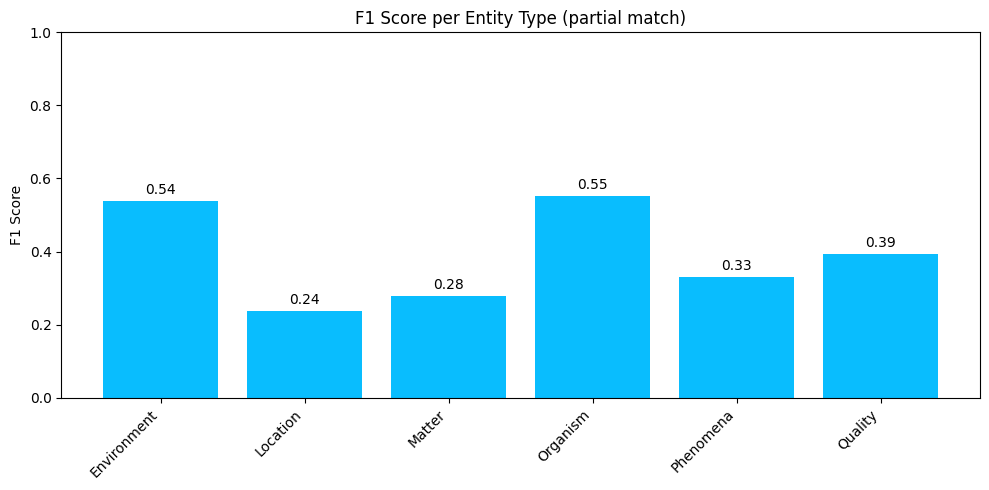

['Environment', 'Location', 'Matter', 'Organism', 'Phenomena', 'Quality']


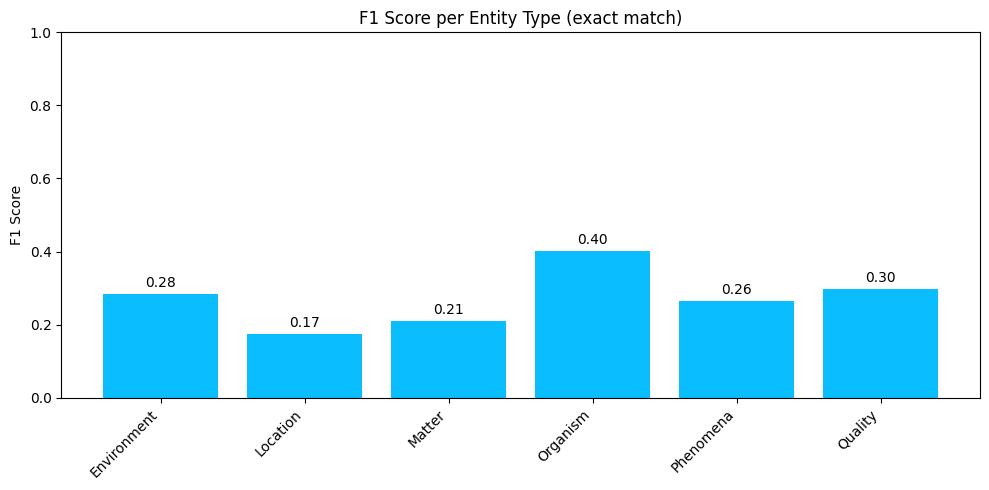

['Environment', 'Location', 'Matter', 'Organism', 'Phenomena', 'Quality']


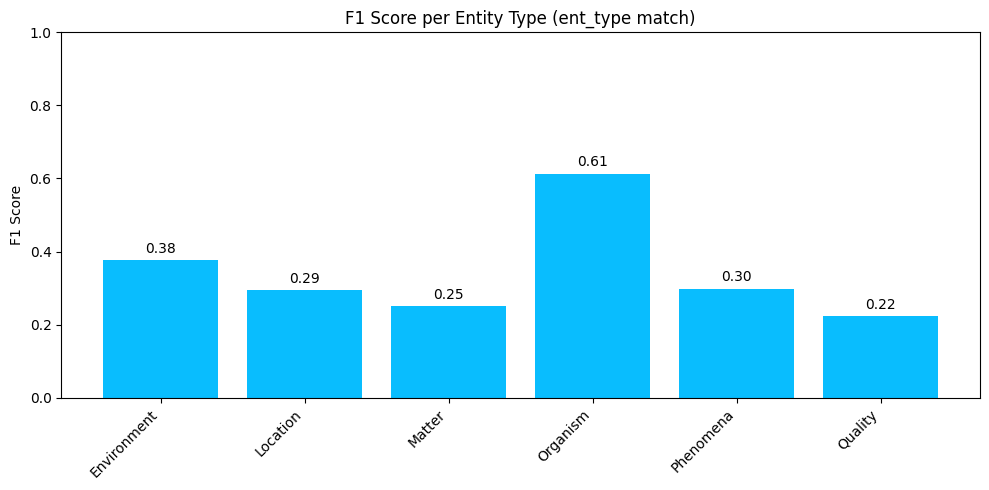

In [22]:
def plot_f1_per_entity(results_by_tag, scheme='strict'):
    labels = list(results_by_tag.keys())
    labels.sort()
    print(labels)
    f1_scores = [results_by_tag[label][scheme]['f1'] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, f1_scores, color='#09bdfe')
    ax.set_ylabel("F1 Score")
    ax.set_title(f"F1 Score per Entity Type ({scheme} match)")
    ax.set_ylim(0, 1)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
for scheme in ['strict', 'partial', 'exact', 'ent_type']:
    plot_f1_per_entity(results_by_tag, scheme)

## Across Dataset Comparison on 50 Papers Sample

### Loading from paper annotation model predictions

This should be applied to any folder containing multiple documents with GLiNER predictions.

In [47]:
DIR = "/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/GLINER_IBMCCNER_P_50P_SAMPLE/"


predictions = dict()

for file in tqdm(os.listdir(DIR)):
    with open(DIR + file, "r") as f:
        data = json.load(f)
        # print(data[1])
    PAPER_ID = str(file.split("_")[1])
    for sent in data:
        sent_id = sent["sentence_id"]
        prediction = {
            "text": sent["sentence"],
            "ner": sent["entities"]
        } 
        predictions[f"sentence-{sent_id}-{PAPER_ID}"] = prediction

    
conll_output = convert_predictions_to_conll(predictions)

os.makedirs("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/IBMCCNER_P/", exist_ok=True)

with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/IBMCCNER_P/pred_50p.txt", "w") as f:
    f.write(conll_output)

100%|██████████| 50/50 [00:00<00:00, 323.07it/s]


### Loading from label studio style annotations

In [23]:
with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/DATA/LABEL_STUDIO/project-6-at-2025-09-18-07-40-e0e30e08.json", "r") as f:
    json_data = json.load(f)

In [61]:

predictions = dict()
for sentence_anot in json_data:

    ## sentence_anot
    # ['id', 'annotations', 'file_upload', 'drafts', 'predictions', 
    # 'data', 'meta', 'created_at', 'updated_at', 'inner_id', 
    # 'total_annotations', 'cancelled_annotations', 'total_predictions', 'comment_count', 'unresolved_comment_count', 
    # 'last_comment_updated_at', 'project', 'updated_by', 'comment_authors']
    PAPER_ID = sentence_anot["data"]["paper_id"]
    SENT_ID = sentence_anot["data"]["sentence_id"]
    
    ner = []
    for entity_anot in sentence_anot["annotations"][0]["result"]:#["sentence"])
        if "value" in entity_anot.keys():
            value = entity_anot["value"]

            entity_anot_dict = {
                'start': value["start"],
                'end': value["end"],
                'text': value["text"],
                'label': value["labels"][0] 
            }
            ner.append(entity_anot_dict)
            
        prediction = {
            "text": sentence_anot["data"]["sentence"],
            "ner": ner
        }
        
        predictions[f"sentence-{SENT_ID}-{PAPER_ID}"] = prediction
        


In [63]:
conll_output = convert_predictions_to_conll(predictions)

os.makedirs("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/", exist_ok=True)

with open("/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/pred_50p.txt", "w") as f:
    f.write(conll_output)

### Parsing CONLL files

Now when everyzhing is in the same format, only difference is that annotations are incomplete -> meaning everything should be filtered by annotations.

In [3]:

def parse_conll_file_with_ids(file_path: str) -> Dict[str, Dict]:
    """
    Parses a CoNLL-style file and returns a dictionary mapping document IDs
    to their tokens and entity spans.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Returning empty data.")
        return {}

    # Split by a more specific DOCSTART pattern to get the ID
    docs_as_strings = content.strip().split('\n-DOCSTART - ')[1:]
    parsed_data = {}

    for doc_string in docs_as_strings:
        lines = doc_string.strip().split('\n')
        
        # The first line contains the ID, e.g., "sentence-0-1072 -\tO"
        header_parts = lines[0].split(' -')
        if len(header_parts) < 2:
            continue
        doc_id = header_parts[0] # e.g., "sentence-0-1072"

        tokens = []
        tags = []
        for line in lines[1:]: # Skip the header line
            parts = line.split('\t')
            if len(parts) == 2:
                tokens.append(parts[0])
                tags.append(parts[1])
        
        if tokens:
            entities = set(get_entities(tags))
            parsed_data[doc_id] = {"tokens": tokens, "entities": entities}
            
    return parsed_data

def compare_and_plot_overlap(
    file_a_path: str,
    file_a_name: str,
    file_a_labels: Set[str],
    file_b_path: str,
    file_b_name: str,
    file_b_labels: Set[str]
):
    """
    Main function to load, filter, align, and plot the entity overlap
    between two CoNLL-formatted annotation files.
    """
    print("--- Phase 1: Parsing Data ---")
    data_a = parse_conll_file_with_ids(file_a_path)
    data_b = parse_conll_file_with_ids(file_b_path)
    print(f"Loaded {len(data_a)} documents from {file_a_name}.")
    print(f"Loaded {len(data_b)} documents from {file_b_name}.")

    # --- Phase 2: Filtering and Alignment ---
    print("\n--- Phase 2: Filtering and Aligning Spans ---")
    
    # Filter B by A's IDs if 'ANOT' is in A's name, or vice-versa
    if 'ANOT' in file_a_name.upper():
        print(f"Filtering {file_b_name} to match document IDs in {file_a_name}...")
        common_ids = set(data_a.keys()) & set(data_b.keys())
        data_b = {doc_id: data_b[doc_id] for doc_id in common_ids}
        data_a = {doc_id: data_a[doc_id] for doc_id in common_ids}
        print(f"Found {len(common_ids)} common documents.")
    elif 'ANOT' in file_b_name.upper():
        print(f"Filtering {file_a_name} to match document IDs in {file_b_name}...")
        common_ids = set(data_a.keys()) & set(data_b.keys())
        data_a = {doc_id: data_a[doc_id] for doc_id in common_ids}
        data_b = {doc_id: data_b[doc_id] for doc_id in common_ids}
        print(f"Found {len(common_ids)} common documents.")
        
    # Align entities by their exact token spans
    aligned_spans = {}
    for doc_id in data_a.keys():
        if doc_id not in data_b:
            continue

        labels_a_map = { (start, end): label for label, start, end in data_a[doc_id]['entities'] }
        labels_b_map = { (start, end): label for label, start, end in data_b[doc_id]['entities'] }
        
        all_spans = set(labels_a_map.keys()) | set(labels_b_map.keys())

        for span in all_spans:
            span_key = (doc_id, span[0], span[1])
            aligned_spans[span_key] = {
                'A': labels_a_map.get(span, 'O'),
                'B': labels_b_map.get(span, 'O')
            }

    print(f"Aligned a total of {len(aligned_spans)} unique entity spans across all documents.")

    # --- Phase 3: Analysis and Visualization ---
    print("\n--- Phase 3: Generating Mapping Matrix ---")
    
    # Add 'O' for "Outside" / "Not an Entity"
    labels_a_with_o = sorted(list(file_a_labels)) + ['O']
    labels_b_with_o = sorted(list(file_b_labels)) + ['O']
    
    matrix = pd.DataFrame(0, index=labels_a_with_o, columns=labels_b_with_o)
    
    for span_info in aligned_spans.values():
        label_a = span_info['A']
        label_b = span_info['B']
        if label_a in matrix.index and label_b in matrix.columns:
            matrix.loc[label_a, label_b] += 1
            
    print("Matrix generated successfully.")
    
    # Plotting
    plt.figure(figsize=(16, 14))
    heatmap = sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', linewidths=.5)
    
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    
    plt.ylabel(f'{file_a_name} Labels (Source)', fontsize=12)
    plt.xlabel(f'{file_b_name} Labels (Target)', fontsize=12)
    title = f"Entity Label Mapping: {file_a_name} vs {file_b_name}"
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()

    # Saving
    output_dir = 'PLOTS'
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{file_a_name}_vs_{file_b_name}_mapping_matrix.png"
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300)
    print(f"\nPlot saved to: {save_path}")
    plt.close()


# --- Run the comparisons ---

# 1. Compare Annotations vs. IBM Predictions
#    (The code will automatically filter PRED_IBM down to the sentences in ANOT)
compare_and_plot_overlap(
    file_a_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/pred_50p.txt",
    file_a_name="ANOT",
    file_a_labels=CWED4ETA_LABELS,
    file_b_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/IBMCCNER_P/pred_50p.txt",
    file_b_name="PRED_IBM",
    file_b_labels=IBMCCNER_LABELS
)

# 2. Compare Annotations vs. BiodivNER Predictions
#    (The code will automatically filter PRED_BIO down to the sentences in ANOT)
compare_and_plot_overlap(
    file_a_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/pred_50p.txt",
    file_a_name="ANOT",
    file_a_labels=CWED4ETA_LABELS,
    file_b_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/BIODIVNER_P/pred_50p.txt",
    file_b_name="PRED_BIO",
    file_b_labels=BIODIVNER_LABELS
)

--- Phase 1: Parsing Data ---
Loaded 729 documents from ANOT.
Loaded 11973 documents from PRED_IBM.

--- Phase 2: Filtering and Aligning Spans ---
Filtering PRED_IBM to match document IDs in ANOT...
Found 722 common documents.
Aligned a total of 8953 unique entity spans across all documents.

--- Phase 3: Generating Mapping Matrix ---
Matrix generated successfully.

Plot saved to: PLOTS/ANOT_vs_PRED_IBM_mapping_matrix.png
--- Phase 1: Parsing Data ---
Loaded 729 documents from ANOT.
Loaded 11973 documents from PRED_BIO.

--- Phase 2: Filtering and Aligning Spans ---
Filtering PRED_BIO to match document IDs in ANOT...
Found 722 common documents.
Aligned a total of 9882 unique entity spans across all documents.

--- Phase 3: Generating Mapping Matrix ---
Matrix generated successfully.

Plot saved to: PLOTS/ANOT_vs_PRED_BIO_mapping_matrix.png


In [6]:
def parse_conll_file_with_ids(file_path: str) -> Dict[str, Dict]:
    # This function remains the same as before
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Returning empty data.")
        return {}
    docs_as_strings = content.strip().split('\n-DOCSTART - ')[1:]
    parsed_data = {}
    for doc_string in docs_as_strings:
        lines = doc_string.strip().split('\n')
        header_parts = lines[0].split(' -');
        if len(header_parts) < 2: continue
        doc_id = header_parts[0]
        tokens, tags = [], []
        for line in lines[1:]:
            parts = line.split('\t');
            if len(parts) == 2: tokens.append(parts[0]); tags.append(parts[1])
        if tokens: parsed_data[doc_id] = {"tokens": tokens, "entities": set(get_entities(tags))}
    return parsed_data

def analyze_label_relationships(
    df_matrix: pd.DataFrame,
    threshold: float,
    source_name: str,
    target_name: str
):
    """
    Analyzes a raw count confusion matrix to find subset and mapping relationships,
    and prints the results in a markdown-like format.
    """
    print(f"\n### Label Relationship Analysis (Threshold: {threshold*100:.0f}%)")

    # Calculate row and column totals, excluding the 'O' category for normalization
    matrix_no_o = df_matrix.drop('O', axis=0, errors='ignore').drop('O', axis=1, errors='ignore')
    row_totals = matrix_no_o.sum(axis=1)
    col_totals = matrix_no_o.sum(axis=0)

    mappings = []
    source_is_subset = []
    target_is_subset = []

    # Iterate over every cell in the matrix (excluding 'O' vs 'O')
    for source_label in matrix_no_o.index:
        for target_label in matrix_no_o.columns:
            count = matrix_no_o.loc[source_label, target_label]
            if count == 0:
                continue

            # Calculate forward (row) and backward (column) percentages
            row_total = row_totals.get(source_label, 0)
            col_total = col_totals.get(target_label, 0)
            
            forward_percent = count / row_total if row_total > 0 else 0
            backward_percent = count / col_total if col_total > 0 else 0

            # Check for relationships based on the threshold
            is_forward_subset = forward_percent >= threshold
            is_backward_subset = backward_percent >= threshold

            # Format the output strings using markdown syntax
            if is_forward_subset and is_backward_subset:
                mappings.append(
                    f"- `{source_label}` (`{source_name}`) **<-->** `{target_label}` (`{target_name}`) "
                    f"(**{forward_percent:.1%}** forward, **{backward_percent:.1%}** backward)"
                )
            elif is_forward_subset:
                source_is_subset.append(
                    f"- `{source_label}` (`{source_name}`) **-->** `{target_label}` (`{target_name}`) "
                    f"(**{forward_percent:.1%}**)"
                )
            elif is_backward_subset:
                target_is_subset.append(
                    f"- `{target_label}` (`{target_name}`) **-->** `{source_label}` (`{source_name}`) "
                    f"(**{backward_percent:.1%}**)"
                )
    
    # Print the report
    if mappings:
        print("\n**Potential Mappings (Likely Equivalent Concepts)**")
        for line in sorted(mappings): print(line)
    
    if source_is_subset:
        print(f"\n**`{source_name}` Labels that are Likely Subsets of `{target_name}` Labels**")
        for line in sorted(source_is_subset): print(line)
        
    if target_is_subset:
        print(f"\n**`{target_name}` Labels that are Likely Subsets of `{source_name}` Labels**")
        for line in sorted(target_is_subset): print(line)
        
    if not mappings and not source_is_subset and not target_is_subset:
        print("\n*No significant relationships found at this threshold.*")
    
    print("\n---") # Markdown for a horizontal rule

def compare_and_plot_overlap(
    file_a_path: str,
    file_a_name: str,
    file_a_labels: Set[str],
    file_b_path: str,
    file_b_name: str,
    file_b_labels: Set[str],
    analysis_threshold: float = 0.50
):
    """
    Main function to load, filter, align, plot, and analyze the entity overlap.
    The output is formatted in a markdown-like style for clarity.
    """
    print("## Phase 1: Parsing Data")
    data_a = parse_conll_file_with_ids(file_a_path)
    data_b = parse_conll_file_with_ids(file_b_path)
    print(f"- Loaded **{len(data_a)}** documents from `{file_a_name}`.")
    print(f"- Loaded **{len(data_b)}** documents from `{file_b_name}`.")

    print("\n## Phase 2: Filtering and Aligning Spans")
    if 'ANOT' in file_a_name.upper():
        common_ids = set(data_a.keys()) & set(data_b.keys())
        data_b = {doc_id: data_b[doc_id] for doc_id in common_ids}
        data_a = {doc_id: data_a[doc_id] for doc_id in common_ids}
        print(f"- Filtered to **{len(common_ids)}** common documents based on `{file_a_name}`.")
    elif 'ANOT' in file_b_name.upper():
        common_ids = set(data_a.keys()) & set(data_b.keys())
        data_a = {doc_id: data_a[doc_id] for doc_id in common_ids}
        data_b = {doc_id: data_b[doc_id] for doc_id in common_ids}
        print(f"- Filtered to **{len(common_ids)}** common documents based on `{file_b_name}`.")

    aligned_spans = {}
    for doc_id in data_a.keys():
        if doc_id not in data_b: continue
        labels_a_map = {(s, e): l for l, s, e in data_a[doc_id]['entities']}
        labels_b_map = {(s, e): l for l, s, e in data_b[doc_id]['entities']}
        all_spans = set(labels_a_map.keys()) | set(labels_b_map.keys())
        for span in all_spans:
            aligned_spans[(doc_id, span[0], span[1])] = {
                'A': labels_a_map.get(span, 'O'), 'B': labels_b_map.get(span, 'O')}

    print(f"- Aligned a total of **{len(aligned_spans)}** unique entity spans.")

    print("\n## Phase 3: Generating and Saving Mapping Matrix")
    labels_a_with_o = sorted(list(file_a_labels)) + ['O']
    labels_b_with_o = sorted(list(file_b_labels)) + ['O']
    matrix = pd.DataFrame(0, index=labels_a_with_o, columns=labels_b_with_o)
    for span_info in aligned_spans.values():
        label_a, label_b = span_info['A'], span_info['B']
        if label_a in matrix.index and label_b in matrix.columns:
            matrix.loc[label_a, label_b] += 1
    
    # Plotting
    plt.figure(figsize=(16, 14))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', linewidths=.5)
    plt.ylabel(f'{file_a_name} Labels (Source)', fontsize=12)
    plt.xlabel(f'{file_b_name} Labels (Target)', fontsize=12)
    title = f"Entity Label Mapping: {file_a_name} vs {file_b_name}"
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()

    # Saving
    output_dir = 'PLOTS'
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{file_a_name}_vs_{file_b_name}_mapping_matrix.png"
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300)
    print(f"- Plot saved to: `{save_path}`")
    plt.close()

    # --- Phase 4: Analyze and Report Relationships ---
    analyze_label_relationships(matrix, analysis_threshold, file_a_name, file_b_name)



# --- Run the comparisons ---

# 1. Compare Annotations vs. IBM Predictions
#    (The code will automatically filter PRED_IBM down to the sentences in ANOT)
compare_and_plot_overlap(
    file_a_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/pred_50p.txt",
    file_a_name="ANOT",
    file_a_labels=CWED4ETA_LABELS,
    file_b_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/IBMCCNER_P/pred_50p.txt",
    file_b_name="PRED_IBM",
    file_b_labels=IBMCCNER_LABELS,
    analysis_threshold=0.66
)

# 2. Compare Annotations vs. BiodivNER Predictions
#    (The code will automatically filter PRED_BIO down to the sentences in ANOT)
compare_and_plot_overlap(
    file_a_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/ANNOTATIONS/pred_50p.txt",
    file_a_name="ANOT",
    file_a_labels=CWED4ETA_LABELS,
    file_b_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/BIODIVNER_P/pred_50p.txt",
    file_b_name="PRED_BIO",
    file_b_labels=BIODIVNER_LABELS,
    analysis_threshold=0.66
)

# 3. Compare IBMCCNER vs. BiodivNER Predictions

compare_and_plot_overlap(
    file_a_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/BIODIVNER_P/pred_50p.txt",
    file_a_name="PRED_BIO",
    file_a_labels=BIODIVNER_LABELS,
    file_b_path="/home/p0l3/RAD/CWED4ETA/CWED4ETA/CWED4ETA/RESULTS/CONLL_FORMAT/GLiNER_med_v2_1/IBMCCNER_P/pred_50p.txt",
    file_b_name="PRED_IBM",
    file_b_labels=IBMCCNER_LABELS,
    analysis_threshold=0.66
)

## Phase 1: Parsing Data
- Loaded **729** documents from `ANOT`.
- Loaded **11973** documents from `PRED_IBM`.

## Phase 2: Filtering and Aligning Spans
- Filtered to **722** common documents based on `ANOT`.
- Aligned a total of **8953** unique entity spans.

## Phase 3: Generating and Saving Mapping Matrix
- Plot saved to: `PLOTS/ANOT_vs_PRED_IBM_mapping_matrix.png`

### Label Relationship Analysis (Threshold: 66%)

**Potential Mappings (Likely Equivalent Concepts)**
- `Organism` (`ANOT`) **<-->** `climate-organisms` (`PRED_IBM`) (**88.7%** forward, **73.4%** backward)

**`ANOT` Labels that are Likely Subsets of `PRED_IBM` Labels**
- `Astronomical Object` (`ANOT`) **-->** `climate-nature` (`PRED_IBM`) (**100.0%**)
- `Body Part` (`ANOT`) **-->** `climate-nature` (`PRED_IBM`) (**75.0%**)
- `Body of Water` (`ANOT`) **-->** `climate-nature` (`PRED_IBM`) (**93.4%**)
- `Disease` (`ANOT`) **-->** `climate-hazards` (`PRED_IBM`) (**73.9%**)
- `Ecosystem` (`ANOT`) **-->** `climate-nature` (`PR